# PPE with Yolov26 (V2)
src:
- [Ultralytics PPE Datasets](https://docs.ultralytics.com/datasets/detect/construction-ppe/#dataset-structure)
- [Dataset Zipfile](https://github.com/ultralytics/ultralytics/blob/main/ultralytics/cfg/datasets/construction-ppe.yaml)
- [how to train ppe dataset](https://github.com/ultralytics/notebooks/blob/main/notebooks/how-to-train-ultralytics-yolo-on-construction-ppe-detection-dataset.ipynb) by Ultralytics

try YOLO Nano model for fast inference: https://huggingface.co/NexaAI/yolo26n-npu

In [1]:
import os
from pathlib import Path
import requests
import zipfile
import yaml
import shutil
# DS DV
import pandas as pd
import matplotlib.pyplot as plt
# Datasets CV
import ultralytics
from ultralytics import YOLO
from ultralytics import settings
import cv2
# DL
import torch
# Utils
import random
from collections import Counter
import gc
ultralytics.checks()

Ultralytics 8.4.6  Python-3.11.3 torch-2.10.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
Setup complete  (20 CPUs, 127.9 GB RAM, 640.7/3726.0 GB disk)


In [2]:
settings.reset()
# define path
CURRENT_DIR = Path.cwd()
DATA_DIR = CURRENT_DIR / "data"
LOGS_DIR = CURRENT_DIR / "logs"
OUTPUTS_DIR = CURRENT_DIR / "outputs"
MODELS_DIR = CURRENT_DIR / "models"
# create dirs if not exists
DATA_DIR.mkdir(parents=True, exist_ok=True)
LOGS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

### 1. Download and extract datasets
- [Ultralytics PPE Dataset]("https://github.com/ultralytics/assets/releases/download/v0.0.0/construction-ppe.zip")

In [3]:
# download the ppe dataset
ppe_dataset_url = "https://github.com/ultralytics/assets/releases/download/v0.0.0/construction-ppe.zip"
ppe_dataset_dir = DATA_DIR / "construction-ppe"
ppe_dataset_dir.mkdir(parents=True, exist_ok=True)
ppe_zipfile_path = ppe_dataset_dir / "construction-ppe.zip"

In [4]:
# Uncomment the code below to download the dataset if not exists
print("Downloading PPE Contruction dataset from Ultralytics...")
response = requests.get(ppe_dataset_url)

with open(ppe_zipfile_path, "wb") as f:
    f.write(response.content)

In [11]:
# extract the zip file
# uncomment the cell if the you need to extract the zip
print("extracting dataset...")
with zipfile.ZipFile(ppe_zipfile_path, "r") as zip_ref:
    zip_ref.extractall(ppe_dataset_dir)
print("Done!")

extracting dataset...
Done!


### 2. Explore the Data (EDA)

In [8]:
# read yaml config file
yaml_path =  DATA_DIR / "construction-ppe" / "sscv_data.yaml"
try:
    with open(yaml_path, "r", encoding="utf-8") as f:
        dataset_config = yaml.safe_load(f)

except UnicodeDecodeError as e:
    print(f"Unicode Error: {e}")
print("="*70)
print("CONSTRUCTION PPE DATASET")
print("="*70)
print(f"\nDataset config:")
print(f"  nbr of Classes: {len(dataset_config['names'])} == nc: {dataset_config['nc']}")
for class_id, class_name in dataset_config["names"].items():
    print(f"{'':8}{class_id}: {class_name}")

CONSTRUCTION PPE DATASET

Dataset config:
  nbr of Classes: 5 == nc: 5
        0: helmet
        1: gloves
        2: vest
        3: boots
        4: goggles


- train model params: https://docs.ultralytics.com/modes/train/#train-settings

In [11]:
#  ensure a copy of the dataset
# original folders
IMAGES_DIR = ppe_dataset_dir / "images"
LABELS_DIR = ppe_dataset_dir / "labels"
# cleaned v1 dirs
V2_DIR = ppe_dataset_dir / "v2"
V2_IMAGES = V2_DIR / "images"
V2_LABELS = V2_DIR / "labels"
# selected ppe classes
PPE_V2_CLASSES = {0, 1, 2, 3, 4}
SPLITS = ["train", "val", "test"]

In [12]:
# create dir stucture
for split in SPLITS:
    (V2_IMAGES / split).mkdir(parents=True, exist_ok=True)
    (V2_LABELS / split).mkdir(parents=True, exist_ok=True)
print(f"V2 dir created!")

V2 dir created!


In [13]:
# clean label and copy matching images
def clean_split(split):
    src_img_dir = IMAGES_DIR / split
    src_lbl_dir = LABELS_DIR / split
    dst_img_dir = V2_IMAGES / split
    dst_lbl_dir = V2_LABELS / split

    kept_images = 0
    missing_images = []
    for label_path in src_lbl_dir.glob("*.txt"):
        lines = label_path.read_text().splitlines()
        # filter and keep only desired classes
        filtered = [line for line in lines if int(line.split()[0]) in PPE_V2_CLASSES]
        # skip empty labels
        if not filtered:
            continue
        # search for image first
        image_name = label_path.stem
        img_src_path = None
        for ext in [".jpg", ".png", ".jpeg"]:
            temp_path = src_img_dir / f"{image_name}{ext}"
            if temp_path.exists():
                img_src_path = temp_path
                break
        # only copy and write if img and lbl exist
        if img_src_path:
            # copy img
            shutil.copy(img_src_path, dst_img_dir / img_src_path.name)
            # write label now
            dst_label_path = dst_lbl_dir / label_path.name
            dst_label_path.write_text("\n".join(filtered))
            kept_images += 1
        else:
            missing_images.append(label_path.name)

    print(f"{split}: processed {kept_images} valid pairs")
    if missing_images:
        print(f"   Skipped {len(missing_images)} labels because images were missing (e.g.: {missing_images[:3]})")

In [14]:
# delete v1 dirs
if V2_DIR.exists():
    shutil.rmtree(V2_DIR)
for split in SPLITS:
    # re-create dirs
    (V2_IMAGES / split).mkdir(parents=True, exist_ok=True)
    (V2_LABELS / split).mkdir(parents=True, exist_ok=True)
    clean_split(split)

train: processed 946 valid pairs
   Skipped 10 labels because images were missing (e.g.: ['image940(1).txt', 'image941(1).txt', 'image944(1).txt'])
val: processed 121 valid pairs
test: processed 123 valid pairs


In [15]:
# check images
for split in SPLITS:
    n_images = len(list((V2_IMAGES / split).glob("*")))
    n_labels = len(list((V2_LABELS / split).glob("*.txt")))
    print(f"{split}: {n_images} images | {n_labels} labels")

train: 946 images | 946 labels
val: 121 images | 121 labels
test: 123 images | 123 labels


In [16]:
# one image 1 label
img_stems = {p.stem for p in (V2_IMAGES / "train").glob("*")}
lbl_stems = {p.stem for p in (V2_LABELS / "train").glob("*.txt")}

print("Orphan labels:", lbl_stems - img_stems)
print("Missing labels:", img_stems - lbl_stems)

Orphan labels: set()
Missing labels: set()


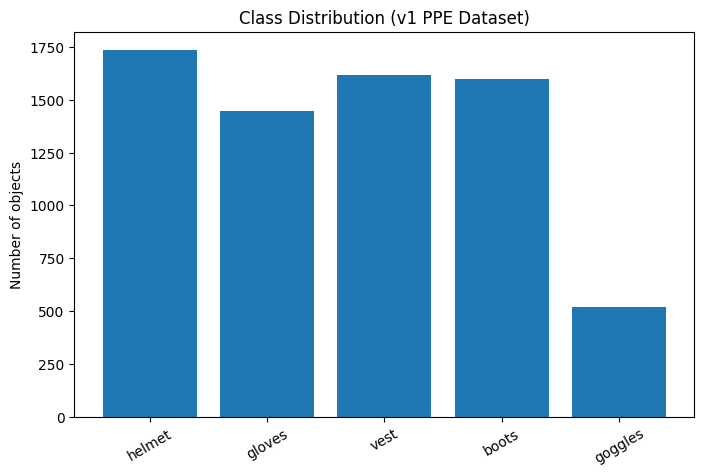

In [17]:
# visualize class distribution
class_counter = Counter()

for split in SPLITS:
    for label_file in (V2_LABELS / split).glob("*.txt"):
        for line in label_file.read_text().splitlines():
            cls_id = int(line.split()[0])
            class_counter[cls_id] += 1

class_names = {
    0: "helmet",
    1: "gloves",
    2: "vest",
    3: "boots",
    4: "goggles"
}

labels = [class_names[k] for k in sorted(class_counter)]
values = [class_counter[k] for k in sorted(class_counter)]

plt.figure(figsize=(8, 5))
plt.bar(labels, values)
plt.title("Class Distribution (v1 PPE Dataset)")
plt.ylabel("Number of objects")
plt.xticks(rotation=30)
plt.show()

In [18]:
def show_random_image(split="train"):
    images = list((V2_IMAGES / split).glob("*"))
    img_path = random.choice(images)

    label_path = (V2_LABELS / split / img_path.stem).with_suffix(".txt")
    img = cv2.imread(str(img_path))
    h, w, _ = img.shape

    # https://docs.ultralytics.com/datasets/detect/
    for line in label_path.read_text().splitlines():
        cls, x, y, bw, bh = map(float, line.split())

        x1 = int((x - bw/2) * w)
        y1 = int((y - bh/2) * h)
        x2 = int((x + bw/2) * w)
        y2 = int((y + bh/2) * h)

        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(
            img,
            class_names[int(cls)],
            (x1, y1 - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2,
        )

    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

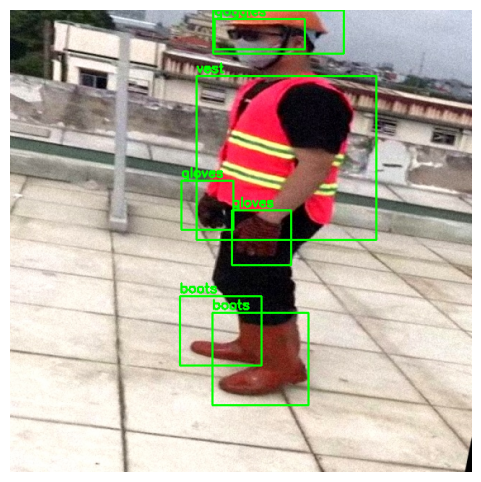

In [19]:
show_random_image("train")

### 3. Download a pre-trained model, configure and train

In [20]:
# update ultralytics settings
settings.update({
    "datasets_dir": str(DATA_DIR.absolute()),
    "weights_dir": str(MODELS_DIR.absolute()),
    "runs_dir": str(LOGS_DIR.absolute()),
    "hub": False,
    "sync": False,
    "mlflow": False,
    "neptune": False,
    "clearml": False,
    "comet": False,
    "raytune": False,
    "wandb": False,
    "tensorboard": True # create tensorboard event
})

In [21]:
# download yolo26n
model_name = "yolo26n.pt"
model_path = MODELS_DIR / model_name
print(f"Downloading {model_name}...")
if model_path.exists():
    print(f"Model already exists!")
    model = YOLO(str(model_path))
else:
    try:
        print(f"Downloading model {model_name} from ultralytics (GitHub)...")
        yolo26_url = f"https://github.com/ultralytics/assets/releases/download/v8.4.0/{model_name}"
        response = requests.get(yolo26_url)
        # write content to current dir (you can provide a custom path too)
        with open(model_path, "wb") as f:
            f.write(response.content)
            model = YOLO(str(model_path))
            print("Model downloaded and loaded successfully!")
    except Exception as e:
        print(f"Download failed: {e}")

Model downloaded and loaded successfully!


In [23]:
# configure Tensorboard
# src: https://github.com/tensorflow/tensorboard?tab=readme-ov-file#tensorboard-is-showing-only-some-of-my-data-or-isnt-properly-updating
%load_ext tensorboard
%tensorboard --logdir=str(LOGS_DIR) --port=6006 --reload_multifile=True --reload_interval=5

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [24]:
# clear caches
torch.cuda.empty_cache()
gc.collect()
# train params
train_args = {
    # model & data
    "model": str(MODELS_DIR / model_name),
    "data": str(yaml_path),

    # training length
    "epochs": 100,
    "patience": 10,

    # image & batch
    "imgsz": 640,
    "batch": 16,
    "device": 0 if torch.cuda.is_available() else "cpu",

    # optimization
    "optimizer": "AdamW",
    "lr0": 0.005,
    "lrf": 0.01, 
    "weight_decay": 0.05, # increase regularization for AdamW

    # augmentation
    "mosaic": 1.0,
    "mixup": 0.1,
    "close_mosaic": 10,
    "multi_scale": True,

    # performance
    "amp": True,
    "workers": 8,

    # reproducibility & logging
    "seed": 42,
    "project": str(LOGS_DIR),
    "name": "yolo26n_ppe_v2",
    "exist_ok": True,
    "save": True,

    # validation
    "val": True,
    "plots": True,
}
%reload_ext tensorboard

In [ ]:
print("Starting Training...")
# start training
results = model.train(**train_args)
print("Training complete!")

### 4. Visualize the train result

In [26]:
TRAIN_RESULTS_DIR = LOGS_DIR / "yolo26n_ppe_v2"
train_results_df = pd.read_csv(os.path.join(TRAIN_RESULTS_DIR, "results.csv"))
train_results_df.head(3)


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,75.8913,2.00339,3.38861,0.01385,0.16235,0.33923,0.19530,0.08631,1.91156,3.93973,0.01630,0.001639,0.001639,0.068861
1,2,99.7125,1.97004,2.43605,0.01318,0.37594,0.22268,0.23347,0.09877,1.96390,3.04893,0.01665,0.003273,0.003273,0.037162
2,3,122.0050,1.96356,2.30095,0.01364,0.33546,0.31369,0.24694,0.09853,1.99125,2.83151,0.01664,0.004874,0.004874,0.005429


<Figure size 1200x500 with 0 Axes>

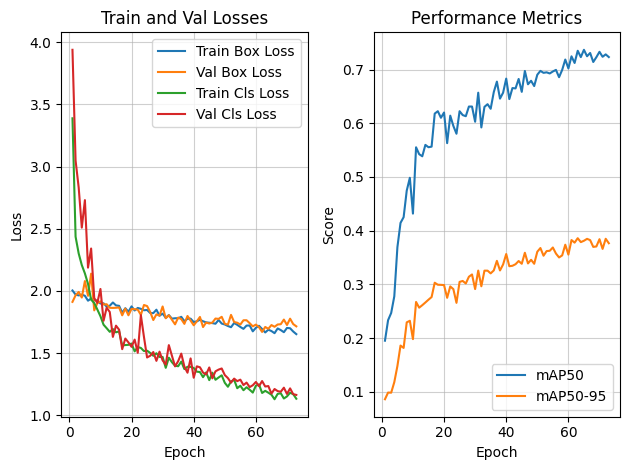

In [27]:
# plot train and val loss
plt.figure(figsize=(12, 5))

fig, ax = plt.subplots(1, 2)
# losses
ax[0].plot(train_results_df["epoch"], train_results_df["train/box_loss"], label="Train Box Loss")
ax[0].plot(train_results_df["epoch"], train_results_df["val/box_loss"], label="Val Box Loss")
ax[0].plot(train_results_df["epoch"], train_results_df["train/cls_loss"], label="Train Cls Loss")
ax[0].plot(train_results_df["epoch"], train_results_df["val/cls_loss"], label="Val Cls Loss")
ax[0].set_title("Train and Val Losses")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()
ax[0].grid(True, alpha=0.6)
# metrics
ax[1].plot(train_results_df["epoch"], train_results_df["metrics/mAP50(B)"], label="mAP50")
ax[1].plot(train_results_df["epoch"], train_results_df["metrics/mAP50-95(B)"], label="mAP50-95")
ax[1].set_title("Performance Metrics")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Score")
ax[1].legend()
ax[1].grid(True, alpha=0.6)

plt.tight_layout()
plt.show()

### 5. Eval, predict export model

In [28]:
# copy best result modelt outputs dir
train_model_path = TRAIN_RESULTS_DIR / "weights" / "best.pt"
model_output_name = "sscv_yolo26n.pt"
# copy the best to output dir
shutil.copy(train_model_path, OUTPUTS_DIR / model_output_name)
print("Model saved in Output Dir!")

Model saved in Output Dir!


In [29]:
# import saved model
# src: https://docs.ultralytics.com/modes/val/
model = YOLO(str(OUTPUTS_DIR / model_output_name))

In [ ]:
print(f"Evaluation model: {model_name}...")
metrics = model.val(
    data=str(yaml_path),
    split="val",
    imgsz=640,
    batch=32,
    conf=0.001,
    iou=0.6,
    device="0" if torch.cuda.is_available() else "cpu",
    verbose=True,
    save_json=False,
    plots=True
)

In [31]:
len(os.listdir(V2_IMAGES / "test"))

123

In [ ]:
# predicts
prediction_results = model.predict(
    source=str(V2_IMAGES / "test"),
    imgsz=640,
    conf=0.25,
    iou=0.6,
    verbose=True,
    save=True,
    save_txt=True,
    project=str(LOGS_DIR),
    name="yolo26n_ppe_v2_pred"
)

In [33]:
real_life_test_pic_path = DATA_DIR / "testpics"

In [ ]:
# unknown pics
last_check_results = model.predict(
    source=str(real_life_test_pic_path),
    conf=0.25,
    verbose=True,
    project=str(real_life_test_pic_path),
    name="pred_results_yolo26n_v2",
    save=True
)
print(f"{last_check_results}")

In [41]:
len(last_check_results)

2

In [35]:
for box in last_check_results[0].boxes:
    print(f"CLS: {int(box.cls)} | Conf: {box.conf} | BBOX: {box.xywhn}")

CLS: 0 | Conf: tensor([0.8372], device='cuda:0') | BBOX: tensor([[0.5948, 0.2313, 0.1283, 0.1660]], device='cuda:0')
CLS: 2 | Conf: tensor([0.8172], device='cuda:0') | BBOX: tensor([[0.3595, 0.6013, 0.1024, 0.2737]], device='cuda:0')
CLS: 2 | Conf: tensor([0.8152], device='cuda:0') | BBOX: tensor([[0.8368, 0.7770, 0.2180, 0.4460]], device='cuda:0')
CLS: 2 | Conf: tensor([0.7329], device='cuda:0') | BBOX: tensor([[0.1795, 0.5168, 0.1351, 0.1697]], device='cuda:0')
CLS: 0 | Conf: tensor([0.7108], device='cuda:0') | BBOX: tensor([[0.7677, 0.3368, 0.0470, 0.0670]], device='cuda:0')
CLS: 2 | Conf: tensor([0.5872], device='cuda:0') | BBOX: tensor([[0.5839, 0.6770, 0.2713, 0.6295]], device='cuda:0')
CLS: 0 | Conf: tensor([0.4885], device='cuda:0') | BBOX: tensor([[0.8569, 0.3831, 0.1244, 0.1540]], device='cuda:0')
CLS: 2 | Conf: tensor([0.4217], device='cuda:0') | BBOX: tensor([[0.7624, 0.4532, 0.0657, 0.1384]], device='cuda:0')


In [ ]:
# export model
# src: https://docs.ultralytics.com/modes/export/
model.export(
    format="onnx",
    opset=17,
    simplify=True,
    dynamic=False,
    batch=1,
    nms=False,
    imgsz=640,
    device="cpu"
)